In [1]:
import os
import numpy as np
import pandas as pd
import pysam

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12883']='R1b1a1b1a1a2e2'
haplogroups['NA12884']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
haplogroup_colors = {
    'A':  '#B2182B',
    'B':  '#D6604D',
    'E':  '#F4A582',
    'D':  '#2166AC',
    'C':  '#1F78B4',
    'F':  '#2C7FB8',
    'G':  '#41B6C4',
    'H':  '#1D91C0',
    'I':  '#6A3D9A',
    'J':  '#0C7C59',
    'L':  '#28A745',
    'T':  '#C77C2E',
    'NO': '#4D9221',
    'N':  '#7FBC41',
    'O':  '#008B8B',
    'Q':  '#A6761D',
    'R':  '#8E63B0',
}

In [5]:
ColorDict={'DYZ18_Yq':'#FC9D2B', 'Yqhet_3k1bp':'#03EDF9','Yqhet_2k7bp':'#239902','DYZ1_Yq':'#BABABA','DYZ2_Con':'#0552A5'}
goodYq12Samples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/Yq12_QC_File.txt','r') as inFile:
    for line in inFile:
        goodYq12Samples.append(line.strip().split("_")[0])

print(len(goodYq12Samples))

84


In [6]:
baseDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DYZ17/baseLengths.csv").set_index('Unnamed: 0')

In [7]:
satDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DYZ17/Satellites_Glennis.csv")

In [8]:
import os
import pandas as pd

directory = '/LeeLab/HPRC/chromosomeY/Data/DYZ17/t2tv2/'

subset_dfs = {}

bad_labels = {'ERRSTRUCT', 'NGAP'}

for file in os.listdir(directory):
    if not file.endswith((".tsv", ".bed", ".txt", ".csv")):
        continue

    sample = file.split(".")[0]

    dfpre = pd.read_csv(os.path.join(directory, file), sep='\t')
    df1 = dfpre[
        (dfpre['label'] != 'ERRBASE') &
        (dfpre['#seq'] == sample + "_chrY")
    ].copy()

    df = df1.sort_values(['#seq', 'start', 'end']).reset_index(drop=True)

    cen_idx = df.index[df['assign_label'].str.contains("CEN", na=False)].tolist()
    keep_idx = set(cen_idx)

    for i in cen_idx:
        prev_i = i - 1
        while prev_i >= 0 and str(df.loc[prev_i, 'label']) in bad_labels:
            prev_i -= 1
        if prev_i >= 0:
            keep_idx.add(prev_i)

        next_i = i + 1
        while next_i < len(df) and str(df.loc[next_i, 'label']) in bad_labels:
            next_i += 1
        if next_i < len(df):
            keep_idx.add(next_i)

    sub_df = df.loc[sorted(keep_idx)].copy()

    if not sub_df.empty:
        subset_dfs[sample] = sub_df

final_df = pd.concat(subset_dfs.values(), ignore_index=True) if subset_dfs else pd.DataFrame()

In [9]:
satDF['TotalCentroSize']=[(int(x.split(":")[1].split("-")[1])-int(x.split(":")[1].split("-")[0]))+1 for x in satDF['Coordinates of centromeric region']]
satDF['HORSize']=[(int(x.split(":")[1].split("-")[1])-int(x.split(":")[1].split("-")[0]))+1 for x in satDF['Coordinates of Active α-satellite HOR array']]
satDF['SATSize']=[satDF.at[x,'TotalCentroSize']-satDF.at[x,'HORSize'] for x in satDF.index]
satDF['sample']=[x.split("_")[0] for x in satDF['Coordinates of centromeric region']]
satDF.set_index("sample", inplace=True)

In [10]:
combineList=[]
for sample in baseDF.index:
    combineList.append([sample, baseDF.at[sample, 'DYZ19_ArrayLength'], 'DYZ19', haplogroups[sample][:1],haplogroup_colors[haplogroups[sample][:1]]])
    if sample in goodYq12Samples:
        combineList.append([sample, baseDF.at[sample, 'TotalYq12Length'], 'Yq12', haplogroups[sample][:1], haplogroup_colors[haplogroups[sample][:1]]])

    if sample in satDF.index:
        combineList.append([sample, satDF.at[sample, 'SATSize'], 'SAT', haplogroups[sample][:1], haplogroup_colors[haplogroups[sample][:1]]])
        combineList.append([sample, satDF.at[sample, 'HORSize'], 'HOR', haplogroups[sample][:1], haplogroup_colors[haplogroups[sample][:1]]])

In [11]:
count=0
for sample in set(final_df['#seq']):
    samplename = sample.split("_")[0]
    if samplename in ['NA12883', 'NA12884']:
        continue
        
    final2 = final_df[final_df['#seq']==sample].copy()
    
    if len(final2[final2['label'].str.contains("ERRSTRUCT|NGAP",regex=True)])>0:
        if samplename in satDF.index:
            print(samplename, 'FILTERED_ANNOT')
            print(final2)
            continue
        else:
            print(samplename, 'FILTERED')
            continue
    else:
        if samplename in satDF.index:
            count+=1
            start = final2.iloc[0]['end']
            end = final2.iloc[-1]['start']
            coord = satDF.at[samplename, 'Coordinates of Active α-satellite HOR array']

            chrom, rest = coord.split(':')
            sub_start, sub_end = map(int, rest.split('-'))
            result_spans = []

            if sub_start > start:
                result_spans.append((start, sub_start))
            
            if sub_end < end:
                result_spans.append((sub_end, end))

            total_length = sum(end - start + 1 for start, end in result_spans)
            combineList.append([samplename, total_length, 'nonHOR_CENSAT', haplogroups[samplename][:1], haplogroup_colors[haplogroups[samplename][:1]]])

print(count)

HG03209 FILTERED
NA19443 FILTERED
HG02132 FILTERED
HG01457 FILTERED
HG02145 FILTERED
HG03710 FILTERED
HG02071 FILTERED
HG02965 FILTERED
HG04204 FILTERED
NA18974 FILTERED
HG04199 FILTERED
NA18971 FILTERED
HG02984 FILTERED
HG02015 FILTERED
HG03130 FILTERED
HG03521 FILTERED
NA18989 FILTERED
HG02011 FILTERED
121


In [12]:
goodTSPYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/TSPY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodTSPYSamples.append(line.strip())

print(len(goodTSPYSamples))

110


In [13]:
for row in baseDF.index:
    if row in goodTSPYSamples:
        total_length = int(baseDF.at[row, 'TSPY_Array_Length'])
        combineList.append([row, total_length, 'TSPY_Array', haplogroups[row][:1], haplogroup_colors[haplogroups[row][:1]]])

In [27]:
azfsampleDF=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AZFc_100Samples_blockCount_Architecture.03172026.csv')

In [29]:
azfDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")
azfDF2 = azfDF[azfDF['sample'].isin(azfsampleDF['Unnamed: 0'])].copy()

In [40]:
for sample in set(azfDF2['sample']):
    tempDF = azfDF2[azfDF2['sample']==sample].sort_values(by=['contig','start']).copy()
    tempDF['Length']=[(int(x)-int(y))+1 for x,y in zip(tempDF['end'], tempDF['start'])]
    combineList.append([sample, sum(tempDF['Length']), 'AZFc', haplogroups[sample][:1], haplogroup_colors[haplogroups[sample][:1]]])

In [41]:
df = pd.DataFrame(data=combineList, columns=['sample','length','Region','Haplogroup', 'hapColor'])

In [58]:
#oldTable = pd.read_csv("/temp.csv").set_index("Sample ID")

In [65]:
df2 = df.set_index("sample").copy()

In [68]:
sample_dict = (
    df.reset_index()
      .groupby('sample')
      .apply(lambda x: dict(zip(x['Region'], x['length'])))
      .to_dict()
)

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_19787/2444142384.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: dict(zip(x['Region'], x['length'])))


In [70]:
#oldTable['AZFc_Length']='NOT_QC_Passed'
#oldTable['nonHOR_CENSAT_Length']='NOT_QC_Passed'

#for sample in oldTable.index:
#    if sample in sample_dict and 'AZFc' in sample_dict[sample].keys():
#        oldTable.at[sample,'AZFc_Length'] = sample_dict[sample]['AZFc']#

#    if sample in sample_dict and 'nonHOR_CENSAT' in sample_dict[sample].keys():
#        oldTable.at[sample,'nonHOR_CENSAT_Length'] = sample_dict[sample]['nonHOR_CENSAT'] 

In [72]:
#oldTable.to_csv('/remix.csv')

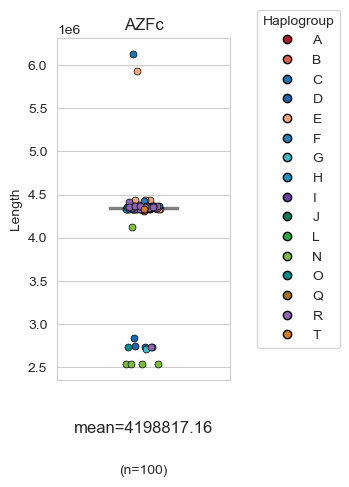

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
regions = ['AZFc']

fig, ax = plt.subplots(1, 1, figsize=(2.5, 5), sharey=False)

legend_info = {}

for region in regions:
    sub = df[df['Region'] == region]

    sns.boxplot(
        data=sub,
        y='length',
        color='lightgray',
        width=0.4,
        fliersize=0,
        ax=ax
    )

    for hap, sub_hap in sub.groupby('Haplogroup'):
        color = sub_hap['hapColor'].iloc[0]

        sns.stripplot(
            data=sub_hap,
            y='length',
            color=color,
            jitter=True,
            size=5,
            edgecolor='black',
            linewidth=0.5,
            ax=ax
        )

        legend_info[hap] = color

    n = sub['sample'].nunique()
    mean_val = sub['length'].mean()

    ax.text(
        0.5, -0.12, f"mean={mean_val:.2f}",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12
    )

    ax.text(
        0.5, -0.25, f"(n={n})",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10
    )

    ax.set_title(region)
    ax.set_xlabel("")
    ax.set_ylabel("Length")


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=hap,
           markerfacecolor=color,
           markeredgecolor='black',
           markersize=6)
    for hap, color in legend_info.items()
]

fig.legend(
    handles=legend_elements,
    title="Haplogroup",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_AZFcOnly.pdf", bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_AZFcOnly.jpg", bbox_inches="tight", dpi=300)
plt.show()

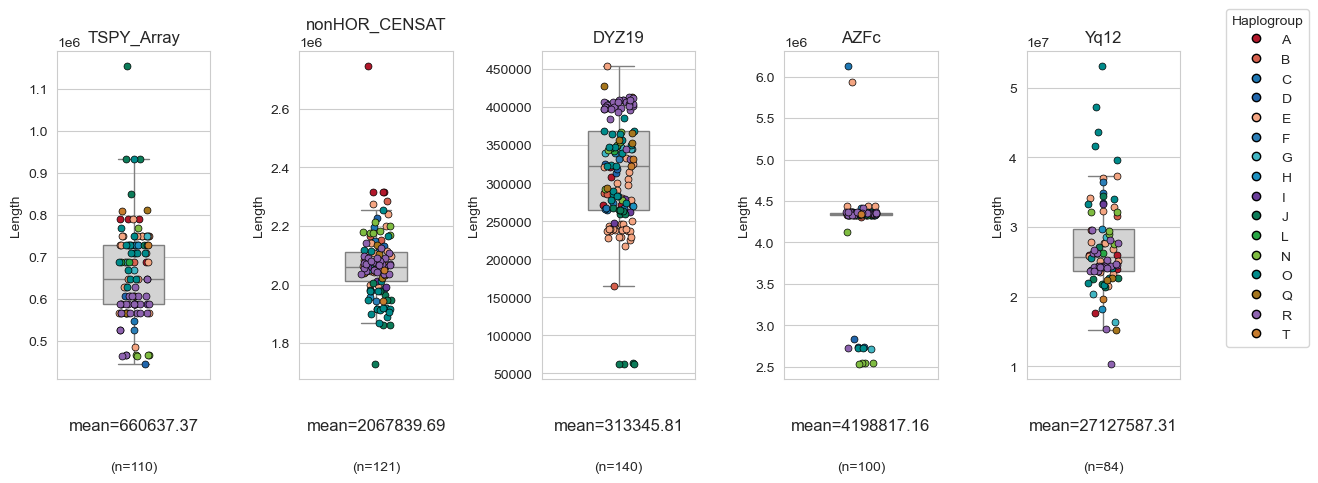

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
regions = ['TSPY_Array','nonHOR_CENSAT','DYZ19', 'AZFc', 'Yq12']

fig, axes = plt.subplots(1, 5, figsize=(12, 5), sharey=False)

legend_info = {}

for ax, region in zip(axes, regions):
    sub = df[df['Region'] == region]
    
    sns.boxplot(
        data=sub,
        y='length',
        color='lightgray',
        width=0.4,
        fliersize=0,
        ax=ax
    )
    
    for hap, sub_hap in sub.groupby('Haplogroup'):
        color = sub_hap['hapColor'].iloc[0]
        
        sns.stripplot(
            data=sub_hap,
            y='length',
            color=color,
            jitter=True,
            size=5,
            edgecolor='black',
            linewidth=0.5,
            ax=ax
        )
        
        legend_info[hap] = color
    
    n = sub['sample'].nunique()
    mean_val = sub['length'].mean()

    ax.text(
        0.5, -0.12, f"mean={mean_val:.2f}",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12
    )

    ax.text(
        0.5, -0.25, f"(n={n})",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10
    )
    
    ax.set_title(region)
    ax.set_xlabel("")
    ax.set_ylabel("Length")


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=hap,
           markerfacecolor=color,
           markeredgecolor='black',
           markersize=6)
    for hap, color in legend_info.items()
]

fig.legend(
    handles=legend_elements,
    title="Haplogroup",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes.pdf", bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes.jpg", bbox_inches="tight", dpi=300)
plt.show()

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_9790/2660936033.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_9790/2660936033.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_9790/2660936033.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_9790/2660936033.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

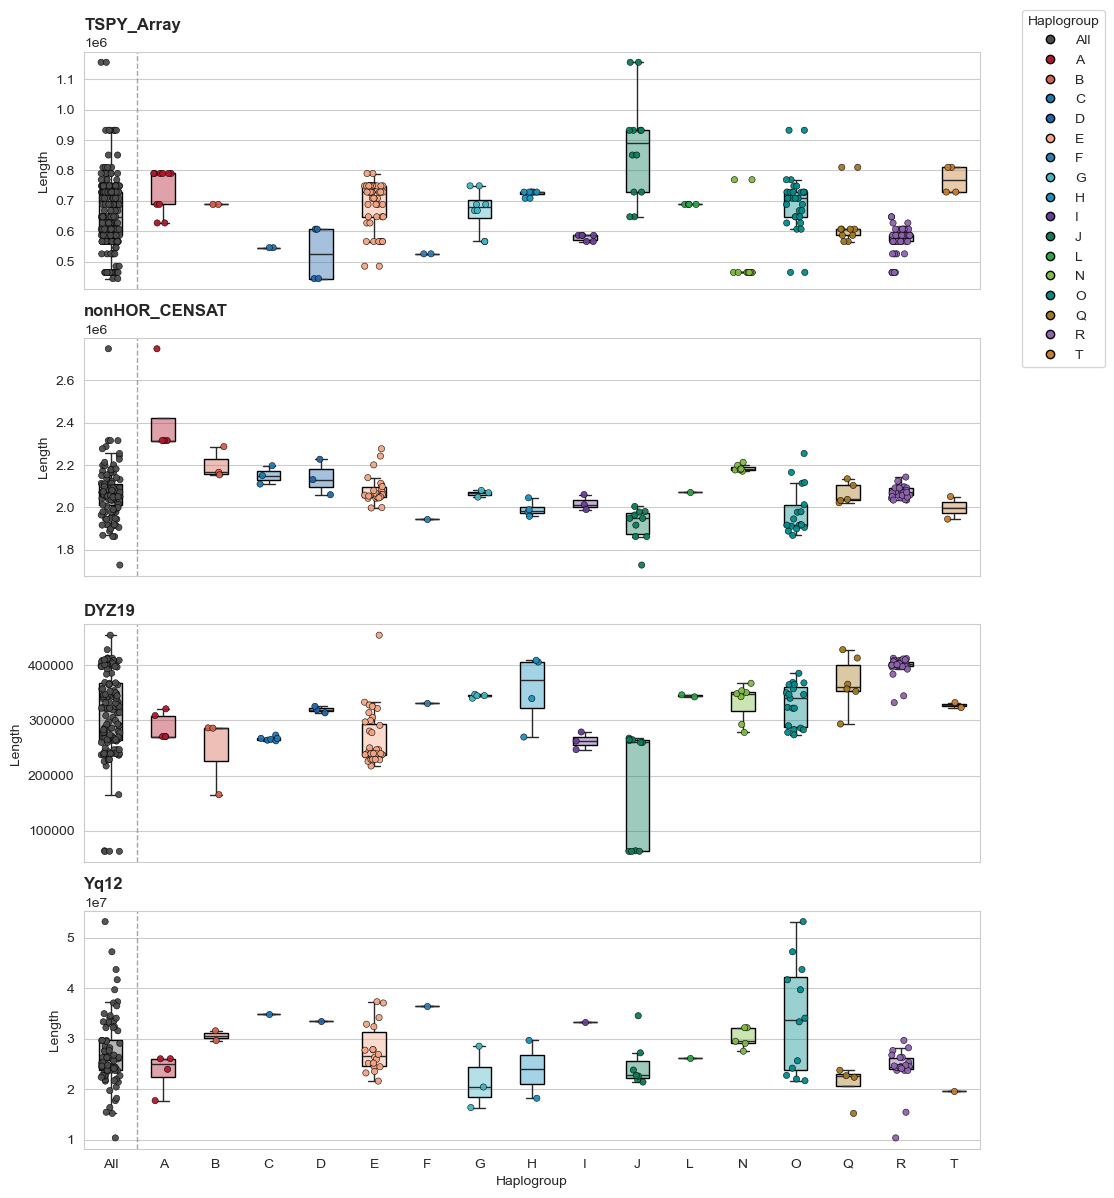

In [249]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

sns.set_style("whitegrid")

regions = ['TSPY_Array', 'nonHOR_CENSAT', 'DYZ19', 'Yq12']

present_haps = [h for h in df['Haplogroup'].dropna().unique()]
hap_order = ['All'] + sorted(present_haps)

hap_palette = {'All': '#4D4D4D'}
for hap in sorted(present_haps):
    hap_palette[hap] = df.loc[df['Haplogroup'] == hap, 'hapColor'].iloc[0]


fig, axes = plt.subplots(len(regions), 1, figsize=(10, 12), sharex=True)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    sub = df[df['Region'] == region].copy()

    # Add "All" version
    sub_all = sub.copy()
    sub_all['Haplogroup'] = 'All'

    sub_plot = pd.concat([sub_all, sub], ignore_index=True)
    sub_plot['Haplogroup'] = pd.Categorical(
        sub_plot['Haplogroup'],
        categories=hap_order,
        ordered=True
    )

    sns.boxplot(
        data=sub_plot,
        x='Haplogroup',
        y='length',
        order=hap_order,
        palette=hap_palette,
        width=0.45,
        fliersize=0,
        linewidth=1,
        ax=ax
    )

    for patch, hap in zip(ax.patches[:len(hap_order)], hap_order):
        patch.set_facecolor(to_rgba(hap_palette[hap], alpha=0.4))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    sns.stripplot(
        data=sub_plot,
        x='Haplogroup',
        y='length',
        order=hap_order,
        hue='Haplogroup',
        palette=hap_palette,
        dodge=False,
        jitter=0.18,
        size=4.5,
        alpha=0.95,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.axvline(
        x=0.5,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.7
    )


    ax.set_title(region, loc='left', fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Length")

axes[-1].set_xlabel("Haplogroup")

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=hap,
        markerfacecolor=hap_palette[hap],
        markeredgecolor='black',
        markersize=6
    )
    for hap in hap_order
]

fig.legend(
    handles=legend_elements,
    title="Haplogroup",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
#plt.savefig(
#    "/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_stacked_by_hap.pdf",
#    bbox_inches="tight"
#)
#plt.savefig(
#    "/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_stacked_by_hap.jpg",
#    bbox_inches="tight",
#    dpi=300
#)
plt.show()

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_19787/3405543202.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


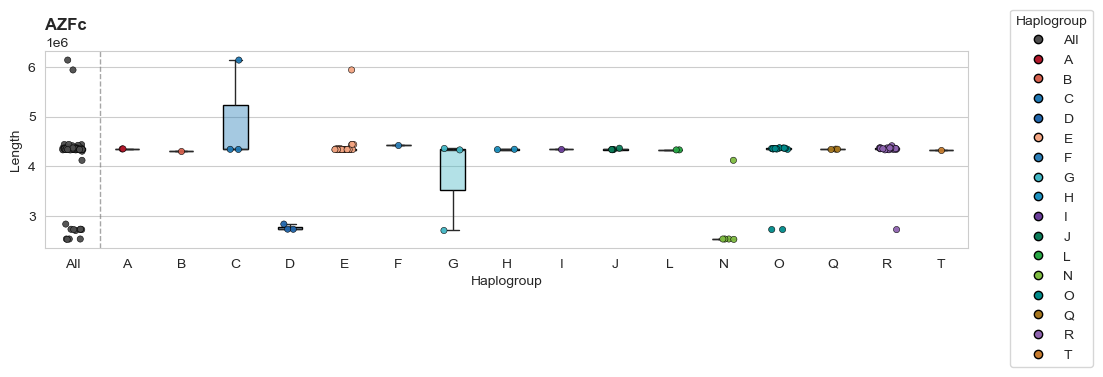

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

sns.set_style("whitegrid")

regions = ['AZFc']

present_haps = [h for h in df['Haplogroup'].dropna().unique()]
hap_order = ['All'] + sorted(present_haps)

hap_palette = {'All': '#4D4D4D'}
for hap in sorted(present_haps):
    hap_palette[hap] = df.loc[df['Haplogroup'] == hap, 'hapColor'].iloc[0]

fig, axes = plt.subplots(len(regions), 1, figsize=(10, 3), sharex=True)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    sub = df[df['Region'] == region].copy()

    sub_all = sub.copy()
    sub_all['Haplogroup'] = 'All'

    sub_plot = pd.concat([sub_all, sub], ignore_index=True)
    sub_plot['Haplogroup'] = pd.Categorical(
        sub_plot['Haplogroup'],
        categories=hap_order,
        ordered=True
    )

    sns.boxplot(
        data=sub_plot,
        x='Haplogroup',
        y='length',
        order=hap_order,
        palette=hap_palette,
        width=0.45,
        fliersize=0,
        linewidth=1,
        ax=ax
    )

    for patch, hap in zip(ax.patches[:len(hap_order)], hap_order):
        patch.set_facecolor(to_rgba(hap_palette[hap], alpha=0.4))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    sns.stripplot(
        data=sub_plot,
        x='Haplogroup',
        y='length',
        order=hap_order,
        hue='Haplogroup',
        palette=hap_palette,
        dodge=False,
        jitter=0.18,
        size=4.5,
        alpha=0.95,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.axvline(
        x=0.5,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.7
    )


    ax.set_title(region, loc='left', fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Length")

axes[-1].set_xlabel("Haplogroup")

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=hap,
        markerfacecolor=hap_palette[hap],
        markeredgecolor='black',
        markersize=6
    )
    for hap in hap_order
]

fig.legend(
    handles=legend_elements,
    title="Haplogroup",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
#plt.savefig(
#    "/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_stacked_by_hap_AZFc_Only.pdf",
#    bbox_inches="tight"
#)
#plt.savefig(
#    "/LeeLab/HPRC/chromosomeY/Data/DYZ17/Repeat_Array_Sizes_stacked_by_hap_AZFc_Only.jpg",
#    bbox_inches="tight",
#    dpi=300
#)
plt.show()